In [34]:
# ============ Imports ============
import gc
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
from collections import Counter
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

import matplotlib.pyplot as plt
import seaborn as sns

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.0
CUDA available: False
MPS available: True


In [35]:
# ============ Configuration ============
FASTA_PATH = "../../data/vgp/all_vgp_tes.fa"
LABEL_PATH = "../../data/vgp/20260120_features_sf"

# Model hyperparameters
FIXED_LENGTH = 20000          # CNN canvas size
MIN_CLASS_COUNT = 100         # Minimum samples per class
LABEL_SMOOTHING = 0.1

# K-mer GNN parameters
KMER_K = 7                   # K-mer size
KMER_DIM = 2048              # Hash dimension
KMER_WINDOW = 512            # Window size for k-mer features
KMER_STRIDE = 256            # Stride for sliding window
GNN_HIDDEN = 128             # GNN hidden dimension
GNN_LAYERS = 3               # Number of GNN layers

# CNN parameters
CNN_WIDTH = 128              # CNN channel width
MOTIF_KERNELS = (7, 15, 21)  # Multi-scale motif detection
CONTEXT_DILATIONS = (1, 2, 4, 8)  # Dilated convolutions
RC_FUSION_MODE = "late"      # "early" or "late" RC fusion

# Fusion parameters
FUSION_DIM = 256             # Attention fusion dimension
NUM_HEADS = 4                # Number of attention heads

# Training parameters
BATCH_SIZE = 16              # Smaller batch for dual-tower model
EPOCHS = 30
LR = 1e-3
DROPOUT = 0.15

def resolve_device(requested=None):
    """Return the best available accelerator."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = resolve_device()
print(f"Using device: {DEVICE}")

Using device: mps


## Data Loading Utilities

In [ ]:
# ============ FASTA and Label Loading ============

def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
    return headers, sequences


def load_hierarchical_labels(label_path, positive_prefixes=("DNA",)):
    """
    Load labels for hierarchical classification.
    
    Args:
        label_path: Path to label file (header<TAB>superfamily).
        positive_prefixes: Only tags starting with one of these prefixes are
            treated as DNA-positive (binary=1). Everything else
            (None, LTR/*, LINE/*, SINE/*, etc.) becomes binary=0.
            Default: ("DNA",) — keeps only DNA transposon superfamilies.
    
    Returns:
        label_dict: header -> tag (superfamily string)
        binary_dict: header -> 0 (non-DNA) or 1 (DNA+)
    """
    label_path = Path(label_path)
    label_dict, binary_dict = {}, {}
    superfamilies = Counter()
    skipped_classes = Counter()
    
    with label_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            
            label_dict[header] = tag
            
            # Check if tag belongs to a positive (DNA) class
            is_positive = any(tag == pfx or tag.startswith(pfx + "/")
                             for pfx in positive_prefixes)
            binary_dict[header] = 1 if is_positive else 0
            superfamilies[tag] += 1
            if not is_positive and tag != "None":
                skipped_classes[tag] += 1
    
    print(f"Loaded {len(label_dict)} sequences")
    print(f"Positive prefixes: {positive_prefixes}")
    print(f"\\nSuperfamily distribution (positive classes):")
    pos_tags = {t for t, _ in superfamilies.items()
                if any(t == p or t.startswith(p + "/") for p in positive_prefixes)}
    for tag, count in sorted(superfamilies.items(), key=lambda x: -x[1]):
        if tag in pos_tags:
            pct = 100 * count / len(label_dict)
            print(f"  ✓ {tag}: {count} ({pct:.1f}%)")
    
    if skipped_classes:
        print(f"\\nNon-DNA classes mapped to binary=0:")
        for tag, count in sorted(skipped_classes.items(), key=lambda x: -x[1]):
            print(f"  ✗ {tag}: {count}")
    
    n_pos = sum(1 for v in binary_dict.values() if v == 1)
    n_neg = len(binary_dict) - n_pos
    print(f"\\nBinary: {n_pos} DNA+ | {n_neg} non-DNA/None")
    
    return label_dict, binary_dict


def compute_class_weights(y_ids, n_classes, mode="inv_sqrt", eps=1e-6):
    """Compute class weights for imbalanced multi-class."""
    counts = np.bincount(np.asarray(y_ids, dtype=np.int64), minlength=n_classes).astype(np.float64)
    if mode == "none":
        w = np.ones(n_classes, dtype=np.float32)
    elif mode == "inv":
        w = 1.0 / (counts + eps)
    elif mode == "inv_sqrt":
        w = 1.0 / np.sqrt(counts + eps)
    else:
        raise ValueError(f"Unknown mode={mode}")
    w = w / (w.mean() + 1e-12)
    return w.astype(np.float32)

## K-mer Featurizer (from GNN model)

In [37]:
# ============ K-mer Feature Extraction ============

# ASCII -> {0,1,2,3,4} for A,C,G,T,other
_ASCII_MAP = np.full(256, 4, dtype=np.uint8)
for ch, val in [("A", 0), ("C", 1), ("G", 2), ("T", 3), ("a", 0), ("c", 1), ("g", 2), ("t", 3)]:
    _ASCII_MAP[ord(ch)] = val

_COMP = np.array([3, 2, 1, 0], dtype=np.uint8)  # A<->T, C<->G


def kmer_code_forward(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4:
        code = (code << 2) | int(v)
    return code


def kmer_code_rc(arr4: np.ndarray) -> int:
    code = 0
    for v in arr4[::-1]:
        code = (code << 2) | int(_COMP[v])
    return code


def canonical_kmer_code(arr4: np.ndarray) -> int:
    c1 = kmer_code_forward(arr4)
    c2 = kmer_code_rc(arr4)
    return c1 if c1 < c2 else c2


def hash_u32(x: int, dim: int) -> int:
    z = (x * 0x9E3779B97F4A7C15) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 33)
    z = (z * 0xC2B2AE3D27D4EB4F) & 0xFFFFFFFFFFFFFFFF
    z ^= (z >> 29)
    return int(z % dim)


@dataclass
class KmerWindowFeaturizer:
    """Extract k-mer frequency features from sliding windows."""
    k: int = 7
    dim: int = 2048
    window: int = 512
    stride: int = 256
    add_pos: bool = True
    l2_normalize: bool = True

    def featurize_sequence(self, seq: str) -> Tuple[np.ndarray, np.ndarray]:
        arr = _ASCII_MAP[np.frombuffer(seq.encode("ascii", "ignore"), dtype=np.uint8)]
        L = int(arr.size)
        
        if L == 0:
            X = np.zeros((1, self.dim + (1 if self.add_pos else 0)), dtype=np.float32)
            return X, np.array([0], dtype=np.int64)

        if L <= self.window:
            starts = np.array([0], dtype=np.int64)
        else:
            starts = np.arange(0, L - self.window + 1, self.stride, dtype=np.int64)
            if starts.size == 0:
                starts = np.array([0], dtype=np.int64)

        out_dim = self.dim + (1 if self.add_pos else 0)
        X = np.zeros((starts.size, out_dim), dtype=np.float32)

        for wi, st in enumerate(starts):
            en = min(st + self.window, L)
            sub = arr[st:en]
            counts = np.zeros(self.dim, dtype=np.float32)
            total = 0

            k = self.k
            if sub.size >= k:
                for i in range(0, sub.size - k + 1):
                    kmer = sub[i:i + k]
                    if np.any(kmer == 4):
                        continue
                    code = canonical_kmer_code(kmer)
                    j = hash_u32(code, self.dim)
                    counts[j] += 1.0
                    total += 1

            if total > 0:
                counts /= float(total)

            if self.l2_normalize:
                nrm = np.linalg.norm(counts)
                if nrm > 0:
                    counts /= nrm

            if self.add_pos:
                center = (st + en) / 2.0
                pos = center / max(1.0, float(L))
                X[wi, :-1] = counts
                X[wi, -1] = pos
            else:
                X[wi, :] = counts

        return X, starts


def build_chain_edge_index(n: int, undirected: bool = True, self_loops: bool = True) -> torch.Tensor:
    """Build edge index for a chain graph (windows connected sequentially)."""
    edges = []
    if n > 1:
        src = np.arange(n - 1, dtype=np.int64)
        dst = np.arange(1, n, dtype=np.int64)
        edges.append((src, dst))
        if undirected:
            edges.append((dst, src))
    if self_loops:
        idx = np.arange(n, dtype=np.int64)
        edges.append((idx, idx))
    if not edges:
        ei = np.zeros((2, 0), dtype=np.int64)
    else:
        s = np.concatenate([e[0] for e in edges])
        d = np.concatenate([e[1] for e in edges])
        ei = np.stack([s, d], axis=0)
    return torch.from_numpy(ei)

## Hybrid Dataset (CNN + GNN features)

In [38]:
# ============ Encoding for CNN ============

# Mapping ACGT to 0-3, N to 4
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

# Reverse complement: ACGTN -> TGCAN -> indices [3, 2, 1, 0, 4]
REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)


class HybridDataset(Dataset):
    """
    Dataset that provides both CNN (one-hot) and GNN (k-mer) features.
    
    For each sequence:
    - CNN: One-hot encoding placed randomly in fixed-length canvas
    - GNN: Pre-computed k-mer window features
    """
    def __init__(
        self,
        headers: List[str],
        sequences: List[str],
        binary_labels: np.ndarray,
        class_labels: np.ndarray,
        kmer_features: List[np.ndarray],  # Pre-computed k-mer features
        fixed_length: int = FIXED_LENGTH
    ):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.binary_labels = np.asarray(binary_labels, dtype=np.int64)
        self.class_labels = np.asarray(class_labels, dtype=np.int64)
        self.kmer_features = kmer_features
        self.fixed_length = fixed_length
        self.seq_lengths = np.array([len(s) for s in sequences], dtype=np.int64)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)

        # Encode sequence for CNN
        seq_bytes = seq.encode("ascii", "ignore")
        seq_idx = ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]

        # Random placement in canvas
        max_start = max(0, self.fixed_length - seq_len)
        start_pos = np.random.randint(0, max_start + 1) if max_start > 0 else 0
        end_pos = start_pos + seq_len

        # K-mer features (pre-computed)
        kmer_feat = self.kmer_features[idx]  # (n_windows, kmer_dim+1)

        return (
            self.headers[idx],
            seq_idx,
            int(self.binary_labels[idx]),
            int(self.class_labels[idx]),
            start_pos,
            end_pos,
            seq_len,
            kmer_feat
        )


def collate_hybrid(batch, fixed_length=FIXED_LENGTH):
    """
    Collate function for hybrid model.
    
    Returns:
        headers: list of header strings
        X_cnn: (B, 5, fixed_length) one-hot for CNN
        mask: (B, fixed_length) padding mask
        Y_binary: (B,) binary labels
        Y_class: (B,) class labels
        x_gnn: (total_nodes, feat_dim) stacked node features
        edge_index: (2, total_edges) graph edges
        batch_vec: (total_nodes,) batch assignment
    """
    (headers, seq_idxs, binary_labels, class_labels, 
     starts, ends, lengths, kmer_feats) = zip(*batch)

    B = len(batch)
    
    # ---- CNN inputs ----
    X_cnn = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((B, fixed_length), dtype=torch.bool)

    for i, (seq_idx, start, end, seq_len) in enumerate(zip(seq_idxs, starts, ends, lengths)):
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X_cnn[i, idx, pos] = 1.0
            mask[i, start:start + actual_len] = (idx != 4)

    Y_binary = torch.tensor(binary_labels, dtype=torch.long)
    Y_class = torch.tensor(class_labels, dtype=torch.long)

    # ---- GNN inputs ----
    xs, eis, batch_vecs = [], [], []
    node_offset = 0

    for gi, kmer_feat in enumerate(kmer_feats):
        x = torch.from_numpy(kmer_feat).to(torch.float32)
        n = x.size(0)
        ei = build_chain_edge_index(n, undirected=True, self_loops=True)
        
        xs.append(x)
        eis.append(ei + node_offset)
        batch_vecs.append(torch.full((n,), gi, dtype=torch.int64))
        node_offset += n

    x_gnn = torch.cat(xs, dim=0)
    edge_index = torch.cat(eis, dim=1) if eis else torch.zeros((2, 0), dtype=torch.int64)
    batch_vec = torch.cat(batch_vecs, dim=0)

    return (
        list(headers), X_cnn, mask, Y_binary, Y_class,
        x_gnn, edge_index, batch_vec
    )

## CNN Tower (from v3 model)

In [39]:
# ============ CNN Building Blocks ============

class ConvBlock(nn.Module):
    """Residual convolutional block with optional dilation."""
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)


class MaskedMaxPool1d(nn.Module):
    """Max pooling that respects padding mask."""
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p


def masked_avg_pool(z, mask):
    """Global average pooling respecting mask."""
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)


class RCFirstConv1d(nn.Module):
    """RC-invariant first convolution (early fusion)."""
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        return y

In [40]:
# ============ CNN Tower ============

class CNNTower(nn.Module):
    """
    CNN tower for sequence motif detection.
    Produces a fixed-size embedding from one-hot encoded DNA sequence.
    """
    def __init__(
        self,
        width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_kernel: int = 9,
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        dropout: float = 0.15,
        rc_mode: str = "late"
    ):
        super().__init__()
        self.rc_mode = rc_mode
        self.out_dim = width
        
        # Motif detection layers
        if rc_mode == "early":
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(5, width, kernel_size=k, padding=k // 2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])
        
        # Mix layer
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # Context blocks with dilation
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)

    @staticmethod
    def rc_transform(x, mask):
        """Apply reverse complement transformation."""
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc

    def encode(self, x, mask):
        """Encode sequence through CNN layers."""
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        
        return masked_avg_pool(z, m)  # (B, width)

    def forward(self, x, mask):
        """
        Forward pass with RC handling.
        Returns: (B, width) embedding
        """
        if self.rc_mode == "late":
            f = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r = self.encode(x_rc, mask_rc)
            return 0.5 * (f + r)
        else:
            return self.encode(x, mask)

## GNN Tower (from k-mer model)

In [41]:
# ============ GNN Building Blocks ============

def scatter_mean(x: torch.Tensor, idx: torch.Tensor, dim_size: int) -> torch.Tensor:
    """Scatter mean for graph pooling."""
    out = torch.zeros((dim_size, x.size(1)), device=x.device, dtype=x.dtype)
    out.index_add_(0, idx, x)
    cnt = torch.bincount(idx, minlength=dim_size).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
    return out / cnt


class GraphSAGELayer(nn.Module):
    """GraphSAGE-style message passing layer."""
    def __init__(self, in_dim: int, out_dim: int, dropout: float = 0.1):
        super().__init__()
        self.lin_self = nn.Linear(in_dim, out_dim)
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        src, dst = edge_index[0], edge_index[1]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, x[src])
        deg = torch.bincount(dst, minlength=x.size(0)).clamp_min(1).to(x.device).to(x.dtype).unsqueeze(1)
        agg = agg / deg
        h = self.lin_self(x) + self.lin_neigh(agg)
        h = F.relu(h)
        return self.dropout(h)


class GNNTower(nn.Module):
    """
    GNN tower for k-mer composition analysis.
    Produces a fixed-size embedding from k-mer window features.
    """
    def __init__(
        self,
        in_dim: int,
        hidden: int = 128,
        n_layers: int = 3,
        dropout: float = 0.1
    ):
        super().__init__()
        self.out_dim = hidden
        
        layers = []
        d = in_dim
        for _ in range(n_layers):
            layers.append(GraphSAGELayer(d, hidden, dropout=dropout))
            d = hidden
        self.layers = nn.ModuleList(layers)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch_vec: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        Args:
            x: (N, in_dim) node features
            edge_index: (2, E) edges
            batch_vec: (N,) batch assignment
        Returns:
            (B, hidden) graph-level embeddings
        """
        for layer in self.layers:
            x = layer(x, edge_index)
        
        B = int(batch_vec.max().item()) + 1 if batch_vec.numel() else 0
        return scatter_mean(x, batch_vec, dim_size=B)

## Attention Fusion Module

In [42]:
# ============ Cross-Modal Attention Fusion ============

class CrossModalAttentionFusion(nn.Module):
    """
    Fuses CNN and GNN embeddings using cross-modal attention.
    
    Features:
    - Projects both embeddings to a common fusion dimension
    - Self-attention across modalities
    - Learned gating for adaptive weighting
    """
    def __init__(
        self,
        cnn_dim: int = 128,
        gnn_dim: int = 128,
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.2
    ):
        super().__init__()
        self.fusion_dim = fusion_dim
        
        # Project both embeddings to fusion dimension
        self.cnn_proj = nn.Linear(cnn_dim, fusion_dim)
        self.gnn_proj = nn.Linear(gnn_dim, fusion_dim)
        
        # Layer norm before attention
        self.ln1 = nn.LayerNorm(fusion_dim)
        self.ln2 = nn.LayerNorm(fusion_dim)
        
        # Cross-modal attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        # Learned gating for adaptive fusion
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.GELU(),
            nn.Linear(fusion_dim, 2),
            nn.Softmax(dim=-1)
        )
        
        # Output projection
        self.out_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

    def forward(self, cnn_embed: torch.Tensor, gnn_embed: torch.Tensor):
        """
        Args:
            cnn_embed: (B, cnn_dim) from CNN tower
            gnn_embed: (B, gnn_dim) from GNN tower
        
        Returns:
            fused: (B, fusion_dim) fused embedding
            gate_weights: (B, 2) for interpretability [cnn_weight, gnn_weight]
        """
        # Project to fusion dimension
        c = self.cnn_proj(cnn_embed)  # (B, fusion_dim)
        g = self.gnn_proj(gnn_embed)  # (B, fusion_dim)
        
        # Layer norm
        c = self.ln1(c)
        g = self.ln2(g)
        
        # Stack as sequence: (B, 2, fusion_dim)
        combined = torch.stack([c, g], dim=1)
        
        # Self-attention across modalities
        attn_out, _ = self.cross_attn(combined, combined, combined)
        
        # Extract attended features
        c_attn = attn_out[:, 0]  # (B, fusion_dim)
        g_attn = attn_out[:, 1]  # (B, fusion_dim)
        
        # Learned gating
        gate_input = torch.cat([c_attn, g_attn], dim=-1)
        gate_weights = self.gate(gate_input)  # (B, 2)
        
        # Weighted fusion
        fused = gate_weights[:, 0:1] * c_attn + gate_weights[:, 1:2] * g_attn
        
        # Output projection
        fused = self.out_proj(fused)
        
        return fused, gate_weights

## Complete Hybrid Model (V4)

In [ ]:
# ============ Hybrid TE Classifier V4 ============

class HybridTEClassifierV4(nn.Module):
    """
    Hybrid TE Classifier combining CNN and K-mer GNN towers.
    
    Architecture:
    1. CNN Tower: Captures local sequence motifs with RC-invariance
    2. GNN Tower: Captures k-mer compositional patterns via message passing
    3. Attention Fusion: Combines both embeddings with learned weighting
    4. Hierarchical Heads: Binary (DNA+/None) and multi-class (superfamily)
    """
    def __init__(
        self,
        num_superfamilies: int,
        # CNN params
        cnn_width: int = 128,
        motif_kernels: Tuple[int, ...] = (7, 15, 21),
        context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
        rc_mode: str = "late",
        # GNN params
        gnn_in_dim: int = 2049,  # kmer_dim + 1 (position)
        gnn_hidden: int = 128,
        gnn_layers: int = 3,
        # Fusion params
        fusion_dim: int = 256,
        num_heads: int = 4,
        dropout: float = 0.15
    ):
        super().__init__()
        self.num_superfamilies = num_superfamilies
        
        # ---- CNN Tower ----
        self.cnn_tower = CNNTower(
            width=cnn_width,
            motif_kernels=motif_kernels,
            context_dilations=context_dilations,
            dropout=dropout,
            rc_mode=rc_mode
        )
        
        # ---- GNN Tower ----
        self.gnn_tower = GNNTower(
            in_dim=gnn_in_dim,
            hidden=gnn_hidden,
            n_layers=gnn_layers,
            dropout=dropout
        )
        
        # ---- Attention Fusion ----
        self.fusion = CrossModalAttentionFusion(
            cnn_dim=cnn_width,
            gnn_dim=gnn_hidden,
            fusion_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout
        )
        
        # ---- Binary Classification Head ----
        self.binary_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
        
        # ---- Superfamily Classification Head ----
        self.superfamily_head = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_superfamilies)
        )

    def forward(
        self,
        x_cnn: torch.Tensor,
        mask: torch.Tensor,
        x_gnn: torch.Tensor,
        edge_index: torch.Tensor,
        batch_vec: torch.Tensor
    ):
        """
        Forward pass.
        
        Args:
            x_cnn: (B, 5, L) one-hot DNA for CNN
            mask: (B, L) padding mask
            x_gnn: (N_nodes, gnn_in_dim) k-mer features
            edge_index: (2, E) graph edges
            batch_vec: (N_nodes,) batch assignment
        
        Returns:
            binary_logits: (B, 2) DNA+ vs None
            superfamily_logits: (B, num_superfamilies)
            gate_weights: (B, 2) fusion weights [CNN, GNN]
        """
        # Get embeddings from both towers
        cnn_embed = self.cnn_tower(x_cnn, mask)  # (B, cnn_width)
        gnn_embed = self.gnn_tower(x_gnn, edge_index, batch_vec)  # (B, gnn_hidden)
        
        # Fuse with attention
        fused, gate_weights = self.fusion(cnn_embed, gnn_embed)  # (B, fusion_dim)
        
        # Classification heads
        binary_logits = self.binary_head(fused)
        superfamily_logits = self.superfamily_head(fused)
        
        return binary_logits, superfamily_logits, gate_weights

## Loss Functions

In [44]:
# ============ Loss Functions ============

class LabelSmoothingCrossEntropy(nn.Module):
    """Cross entropy with label smoothing."""
    def __init__(self, smoothing: float = 0.1, weight: torch.Tensor = None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        n_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        
        # One-hot targets
        targets_one_hot = torch.zeros_like(log_probs).scatter_(1, targets.unsqueeze(1), 1)
        
        # Smooth targets
        targets_smooth = (1 - self.smoothing) * targets_one_hot + self.smoothing / n_classes
        
        # Weighted loss
        if self.weight is not None:
            w = self.weight[targets].unsqueeze(1)
            loss = -(targets_smooth * log_probs * w).sum(dim=-1)
        else:
            loss = -(targets_smooth * log_probs).sum(dim=-1)
        
        return loss.mean()


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(
            logits, targets, weight=self.alpha,
            reduction='none', label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


def save_checkpoint(checkpoint: dict, save_dir: str, name: str):
    """Save model checkpoint."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    path = save_dir / f"{name}.pt"
    torch.save(checkpoint, path)
    print(f"Saved checkpoint to {path}")

## Training Function

In [ ]:
# ============ Training Function (Part 1: Data Preparation) ============

def run_train_v4(
    fasta_path,
    label_path,
    # Training params
    batch_size: int = 16,
    epochs: int = 30,
    lr: float = 1e-3,
    patience: int = 10,
    # CNN params
    cnn_width: int = 128,
    motif_kernels: Tuple[int, ...] = (7, 15, 21),
    context_dilations: Tuple[int, ...] = (1, 2, 4, 8),
    rc_mode: str = "late",
    # GNN params
    kmer_k: int = 7,
    kmer_dim: int = 2048,
    kmer_window: int = 512,
    kmer_stride: int = 256,
    gnn_hidden: int = 128,
    gnn_layers: int = 3,
    # Fusion params
    fusion_dim: int = 256,
    num_heads: int = 4,
    # Loss params
    dropout: float = 0.15,
    binary_weight: float = 1.0,
    superfamily_weight: float = 1.0,
    label_smoothing: float = 0.1,
    # Data params
    min_class_count: int = 20,
    test_size: float = 0.2,
    n_folds: int = 5,
    random_state: int = 42,
    subsample_none: int = None,
    # Other
    device = None,
    save_dir: str = ".",
):
    """
    Train Hybrid V4.1 model combining CNN and K-mer GNN towers.
    
    Improvements over V4:
    - Proper stratification by combined labels (None + each superfamily)
    - K-fold cross-validation with rotating train/val folds
    - Held-out test set only used for final evaluation
    """
    import time
    start_time = time.time()
    
    device = resolve_device(device)
    print(f"Using device: {device}")
    print(f"\\n{'='*60}")
    print("HYBRID TE CLASSIFIER V4.1: CNN + K-mer GNN")
    print("(Improved: K-fold CV + proper stratification)")
    print(f"{'='*60}")
    
    # ---- Load Data ----
    print("\\n=== Loading data ===")
    headers, sequences = read_fasta(fasta_path)
    label_dict, binary_dict = load_hierarchical_labels(label_path)
    
    # Match headers to labels
    all_h, all_s, all_tags, all_binary = [], [], [], []
    for h, s in zip(headers, sequences):
        if h not in label_dict:
            continue
        all_h.append(h)
        all_s.append(s)
        all_tags.append(label_dict[h])
        all_binary.append(binary_dict[h])
    
    del headers, sequences
    gc.collect()
    print(f"Matched {len(all_h)} sequences")
    
    # Subsample None if requested
    if subsample_none is not None:
        none_idx = [i for i, b in enumerate(all_binary) if b == 0]
        tpase_idx = [i for i, b in enumerate(all_binary) if b == 1]
        if len(none_idx) > subsample_none:
            np.random.seed(random_state)
            sampled_none = np.random.choice(none_idx, subsample_none, replace=False)
            keep_idx = sorted(list(tpase_idx) + list(sampled_none))
            all_h = [all_h[i] for i in keep_idx]
            all_s = [all_s[i] for i in keep_idx]
            all_tags = [all_tags[i] for i in keep_idx]
            all_binary = [all_binary[i] for i in keep_idx]
            print(f"Subsampled None: {len(none_idx)} -> {subsample_none}")
    
    # Build superfamily mapping
    tpase_tags = [t for t, b in zip(all_tags, all_binary) if b == 1]
    tag_counts = Counter(tpase_tags)
    keep_superfamilies = {t for t, c in tag_counts.items() if c >= min_class_count}
    superfamily_names = sorted(keep_superfamilies)
    superfamily_to_id = {t: i for i, t in enumerate(superfamily_names)}
    n_superfamilies = len(superfamily_names)
    
    print(f"\\nSuperfamilies ({n_superfamilies}): {superfamily_names}")
    
    # Filter and assign class labels
    filtered_h, filtered_s, filtered_tags, filtered_binary, filtered_class = [], [], [], [], []
    for h, s, tag, binary in zip(all_h, all_s, all_tags, all_binary):
        if binary == 0:
            filtered_h.append(h)
            filtered_s.append(s)
            filtered_tags.append(tag)
            filtered_binary.append(0)
            filtered_class.append(0)
        elif tag in superfamily_to_id:
            filtered_h.append(h)
            filtered_s.append(s)
            filtered_tags.append(tag)
            filtered_binary.append(1)
            filtered_class.append(superfamily_to_id[tag])
    
    all_h = filtered_h
    all_s = filtered_s
    all_binary = np.array(filtered_binary, dtype=np.int64)
    all_class = np.array(filtered_class, dtype=np.int64)
    
    del filtered_h, filtered_s, filtered_tags, filtered_binary, filtered_class
    gc.collect()
    
    print(f"Final: {len(all_h)} sequences")
    print(f"  Binary: {(all_binary == 1).sum()} DNA+ | {(all_binary == 0).sum()} None")
    
    # ---- Pre-compute K-mer Features ----
    print("\\n=== Pre-computing k-mer features ===")
    featurizer = KmerWindowFeaturizer(
        k=kmer_k, dim=kmer_dim, window=kmer_window, stride=kmer_stride,
        add_pos=True, l2_normalize=True
    )
    
    all_kmer_features = []
    for seq in tqdm(all_s, desc="Featurizing", leave=False):
        X, _ = featurizer.featurize_sequence(seq)
        all_kmer_features.append(X)
    
    print(f"K-mer features computed: {len(all_kmer_features)} sequences")
    
    # ---- Create combined stratification labels ----
    # Use "None" for binary=0, superfamily name for binary=1
    # This ensures proper stratification across all classes
    all_strat_labels = []
    for b, c in zip(all_binary, all_class):
        if b == 0:
            all_strat_labels.append("None")
        else:
            all_strat_labels.append(superfamily_names[c])
    all_strat_labels = np.array(all_strat_labels)
    
    # ---- Split off held-out TEST SET ----
    idx_trainval, idx_test = train_test_split(
        np.arange(len(all_h)), test_size=test_size, 
        stratify=all_strat_labels, random_state=random_state
    )
    
    # Extract test set (held out entirely until final evaluation)
    test_h = [all_h[i] for i in idx_test]
    test_s = [all_s[i] for i in idx_test]
    test_binary = all_binary[idx_test]
    test_class = all_class[idx_test]
    test_kmer = [all_kmer_features[i] for i in idx_test]
    
    # Extract trainval set for K-fold CV
    trainval_h = [all_h[i] for i in idx_trainval]
    trainval_s = [all_s[i] for i in idx_trainval]
    trainval_binary = all_binary[idx_trainval]
    trainval_class = all_class[idx_trainval]
    trainval_kmer = [all_kmer_features[i] for i in idx_trainval]
    trainval_strat = all_strat_labels[idx_trainval]
    
    print(f"\\nTrainVal: {len(trainval_h)}, Test (held-out): {len(test_h)}")
    
    # ---- Set up K-fold cross-validation ----
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    fold_splits = list(skf.split(trainval_h, trainval_strat))
    print(f"K-fold CV: {n_folds} folds (rotating validation)")
    
    # Free memory
    del all_h, all_s, all_binary, all_class, all_kmer_features, all_strat_labels
    gc.collect()
    
    # Continue in Part 2...
    return _run_train_v4_part2(
        trainval_h, trainval_s, trainval_binary, trainval_class, trainval_kmer,
        test_h, test_s, test_binary, test_class, test_kmer,
        fold_splits, n_folds,
        n_superfamilies, superfamily_names, superfamily_to_id,
        batch_size, epochs, lr, patience,
        cnn_width, motif_kernels, context_dilations, rc_mode,
        kmer_dim, gnn_hidden, gnn_layers,
        fusion_dim, num_heads, dropout,
        binary_weight, superfamily_weight, label_smoothing,
        device, save_dir, start_time
    )

In [ ]:
# ============ Training Function (Part 2: Training Loop) ============
import heapq

class TopKCheckpointManagerV4:
    """Manages top-K best checkpoints, saving them in real-time."""
    
    def __init__(self, save_dir: str, prefix: str, k: int = 5):
        self.save_dir = Path(save_dir)
        self.save_dir.mkdir(parents=True, exist_ok=True)
        self.prefix = prefix
        self.k = k
        # Min-heap: (score, epoch)
        self.heap = []
        self.checkpoints = {}  # epoch -> checkpoint path
    
    def maybe_save(self, score: float, epoch: int, model, arch_config: dict, 
                   superfamily_names: list, superfamily_to_id: dict, history: dict):
        """Check if this epoch should be saved and save it if so."""
        neg_score = -score
        
        if len(self.heap) < self.k:
            # Not full yet, always save
            self._save_checkpoint(score, epoch, model, arch_config, 
                                  superfamily_names, superfamily_to_id, history)
            heapq.heappush(self.heap, (neg_score, epoch))
            print(f"  💾 Saved checkpoint (top {len(self.heap)}/{self.k})")
            return True
        elif neg_score < self.heap[0][0]:
            # Better than worst in top-k
            _, worst_epoch = heapq.heappop(self.heap)
            self._remove_checkpoint(worst_epoch)
            
            self._save_checkpoint(score, epoch, model, arch_config,
                                  superfamily_names, superfamily_to_id, history)
            heapq.heappush(self.heap, (neg_score, epoch))
            print(f"  💾 Saved checkpoint (replaced epoch {worst_epoch})")
            return True
        return False
    
    def _save_checkpoint(self, score, epoch, model, arch_config, 
                         superfamily_names, superfamily_to_id, history):
        """Save a checkpoint to disk."""
        state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        ckpt = {
            "model_state_dict": state_dict,
            "superfamily_names": superfamily_names,
            "superfamily_to_id": superfamily_to_id,
            "arch": arch_config,
            "history": dict(history),
            "epoch": epoch,
            "score": score,
        }
        path = self.save_dir / f"{self.prefix}_epoch{epoch}.pt"
        torch.save(ckpt, path)
        self.checkpoints[epoch] = path
    
    def _remove_checkpoint(self, epoch: int):
        """Remove a checkpoint file."""
        if epoch in self.checkpoints:
            path = self.checkpoints[epoch]
            if path.exists():
                path.unlink()
            del self.checkpoints[epoch]
    
    def get_best(self):
        """Get the best checkpoint (highest score)."""
        if not self.heap:
            return None, None
        best_neg_score, best_epoch = min(self.heap, key=lambda x: x[0])
        if best_epoch in self.checkpoints:
            ckpt = torch.load(self.checkpoints[best_epoch], weights_only=False)
            return ckpt, best_epoch
        return None, best_epoch
    
    def get_all_saved_epochs(self):
        """Return list of (score, epoch) sorted by score descending."""
        result = [(-neg_score, epoch) for neg_score, epoch in self.heap]
        return sorted(result, reverse=True)


def _run_train_v4_part2(
    trainval_h, trainval_s, trainval_binary, trainval_class, trainval_kmer,
    test_h, test_s, test_binary, test_class, test_kmer,
    fold_splits, n_folds,
    n_superfamilies, superfamily_names, superfamily_to_id,
    batch_size, epochs, lr, patience,
    cnn_width, motif_kernels, context_dilations, rc_mode,
    kmer_dim, gnn_hidden, gnn_layers,
    fusion_dim, num_heads, dropout,
    binary_weight, superfamily_weight, label_smoothing,
    device, save_dir, start_time
):
    """Part 2 of training: model creation and training loop with K-fold CV."""
    
    # ---- Create Test Dataset (held-out, only for final evaluation) ----
    print("\n=== Creating datasets ===")
    ds_test = HybridDataset(test_h, test_s, test_binary, test_class, test_kmer)
    loader_test = DataLoader(
        ds_test, batch_size=batch_size, shuffle=False,
        num_workers=0, collate_fn=collate_hybrid
    )
    print(f"Test set (held-out): {len(ds_test)} samples")
    
    # ---- Create Model ----
    print("\n=== Creating model ===")
    model = HybridTEClassifierV4(
        num_superfamilies=n_superfamilies,
        cnn_width=cnn_width,
        motif_kernels=motif_kernels,
        context_dilations=context_dilations,
        rc_mode=rc_mode,
        gnn_in_dim=kmer_dim + 1,
        gnn_hidden=gnn_hidden,
        gnn_layers=gnn_layers,
        fusion_dim=fusion_dim,
        num_heads=num_heads,
        dropout=dropout
    ).to(device)
    
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {n_params:,}")
    
    # ---- Architecture config for checkpointing ----
    arch_config = {
        "cnn_width": cnn_width,
        "motif_kernels": tuple(motif_kernels),
        "context_dilations": tuple(context_dilations),
        "rc_mode": rc_mode,
        "gnn_in_dim": kmer_dim + 1,
        "gnn_hidden": gnn_hidden,
        "gnn_layers": gnn_layers,
        "fusion_dim": fusion_dim,
        "num_heads": num_heads,
        "num_superfamilies": n_superfamilies,
        "fixed_length": FIXED_LENGTH,
    }
    
    # ---- Checkpoint Manager ----
    ckpt_manager = TopKCheckpointManagerV4(save_dir, prefix="hybrid_v4.1", k=5)
    
    # ---- Loss Functions (computed on full trainval set) ----
    n_pos = float((trainval_binary == 1).sum())
    n_neg = float((trainval_binary == 0).sum())
    binary_weight_tensor = torch.tensor(
        [n_pos / (n_pos + n_neg), n_neg / (n_pos + n_neg)],
        dtype=torch.float32, device=device
    )
    binary_loss_fn = nn.CrossEntropyLoss(weight=binary_weight_tensor)
    
    tpase_mask = trainval_binary == 1
    tpase_classes = trainval_class[tpase_mask]
    sf_weights = compute_class_weights(tpase_classes, n_superfamilies, mode="inv_sqrt")
    sf_weights_t = torch.tensor(sf_weights, dtype=torch.float32, device=device)
    
    if label_smoothing > 0:
        superfamily_loss_fn = LabelSmoothingCrossEntropy(smoothing=label_smoothing, weight=sf_weights_t)
    else:
        superfamily_loss_fn = nn.CrossEntropyLoss(weight=sf_weights_t)
    
    # ---- Optimizer ----
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
    
    # ---- Training Loop with Rotating K-Fold CV ----
    print(f"\n=== Training with rotating {n_folds}-fold CV ===" )
    history = {
        "train_loss": [], "train_binary_loss": [], "train_sf_loss": [],
        "val_binary_acc": [], "val_binary_f1": [],
        "val_sf_acc": [], "val_sf_f1": [],
        "gate_weights_cnn": [], "gate_weights_gnn": [],
        "fold_used": []
    }
    
    best_score = -math.inf
    bad = 0
    
    for ep in range(1, epochs + 1):
        # ---- Select current fold (rotating) ----
        fold_idx = (ep - 1) % n_folds
        train_indices, val_indices = fold_splits[fold_idx]
        
        # Create train/val datasets for this fold
        ds_train = HybridDataset(
            [trainval_h[i] for i in train_indices],
            [trainval_s[i] for i in train_indices],
            trainval_binary[train_indices],
            trainval_class[train_indices],
            [trainval_kmer[i] for i in train_indices]
        )
        ds_val = HybridDataset(
            [trainval_h[i] for i in val_indices],
            [trainval_s[i] for i in val_indices],
            trainval_binary[val_indices],
            trainval_class[val_indices],
            [trainval_kmer[i] for i in val_indices]
        )
        
        loader_train = DataLoader(
            ds_train, batch_size=batch_size, shuffle=True,
            num_workers=0, collate_fn=collate_hybrid
        )
        loader_val = DataLoader(
            ds_val, batch_size=batch_size, shuffle=False,
            num_workers=0, collate_fn=collate_hybrid
        )
        
        n_train_tpase = int((trainval_binary[train_indices] == 1).sum())
        
        # ---- Train ----
        model.train()
        running_loss, running_bin, running_sf = 0.0, 0.0, 0.0
        
        pbar = tqdm(loader_train, desc=f"Epoch {ep}/{epochs} (fold {fold_idx+1}/{n_folds})", leave=False)
        for _, X_cnn, mask, Y_bin, Y_sf, x_gnn, edge_index, batch_vec in pbar:
            X_cnn = X_cnn.to(device)
            mask = mask.to(device)
            Y_bin = Y_bin.to(device)
            Y_sf = Y_sf.to(device)
            x_gnn = x_gnn.to(device)
            edge_index = edge_index.to(device)
            batch_vec = batch_vec.to(device)
            
            binary_logits, sf_logits, gate_weights = model(
                X_cnn, mask, x_gnn, edge_index, batch_vec
            )
            
            # Binary loss (all samples)
            bin_loss = binary_loss_fn(binary_logits, Y_bin)
            
            # Superfamily loss (only DNA+ samples)
            dna_mask = Y_bin == 1
            if dna_mask.sum() > 0:
                sf_loss = superfamily_loss_fn(sf_logits[dna_mask], Y_sf[dna_mask])
            else:
                sf_loss = torch.tensor(0.0, device=device)
            
            loss = binary_weight * bin_loss + superfamily_weight * sf_loss
            
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            
            running_loss += loss.item() * X_cnn.size(0)
            running_bin += bin_loss.item() * X_cnn.size(0)
            running_sf += sf_loss.item() * dna_mask.sum().item() if dna_mask.sum() > 0 else 0
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        
        scheduler.step()
        train_loss = running_loss / len(ds_train)
        train_bin = running_bin / len(ds_train)
        train_sf = running_sf / max(1, n_train_tpase)
        
        # ---- Validate on fold's validation set ----
        model.eval()
        all_bin_pred, all_bin_true = [], []
        all_sf_pred, all_sf_true = [], []
        all_gate_cnn, all_gate_gnn = [], []
        
        with torch.no_grad():
            for _, X_cnn, mask, Y_bin, Y_sf, x_gnn, edge_index, batch_vec in loader_val:
                X_cnn = X_cnn.to(device)
                mask = mask.to(device)
                x_gnn = x_gnn.to(device)
                edge_index = edge_index.to(device)
                batch_vec = batch_vec.to(device)
                
                binary_logits, sf_logits, gate_weights = model(
                    X_cnn, mask, x_gnn, edge_index, batch_vec
                )
                
                bin_pred = binary_logits.argmax(dim=1).cpu().numpy()
                sf_pred = sf_logits.argmax(dim=1).cpu().numpy()
                
                all_bin_pred.extend(bin_pred)
                all_bin_true.extend(Y_bin.numpy())
                
                tpase_mask = Y_bin == 1
                all_sf_pred.extend(sf_pred[tpase_mask.numpy()])
                all_sf_true.extend(Y_sf[tpase_mask].numpy())
                
                all_gate_cnn.extend(gate_weights[:, 0].cpu().numpy())
                all_gate_gnn.extend(gate_weights[:, 1].cpu().numpy())
        
        all_bin_pred = np.array(all_bin_pred)
        all_bin_true = np.array(all_bin_true)
        all_sf_pred = np.array(all_sf_pred)
        all_sf_true = np.array(all_sf_true)
        
        bin_acc = accuracy_score(all_bin_true, all_bin_pred)
        bin_f1 = f1_score(all_bin_true, all_bin_pred, average="binary")
        sf_acc = accuracy_score(all_sf_true, all_sf_pred) if len(all_sf_true) > 0 else 0
        sf_f1 = f1_score(all_sf_true, all_sf_pred, average="macro", zero_division=0) if len(all_sf_true) > 0 else 0
        
        avg_gate_cnn = np.mean(all_gate_cnn)
        avg_gate_gnn = np.mean(all_gate_gnn)
        
        history["train_loss"].append(train_loss)
        history["train_binary_loss"].append(train_bin)
        history["train_sf_loss"].append(train_sf)
        history["val_binary_acc"].append(bin_acc)
        history["val_binary_f1"].append(bin_f1)
        history["val_sf_acc"].append(sf_acc)
        history["val_sf_f1"].append(sf_f1)
        history["gate_weights_cnn"].append(avg_gate_cnn)
        history["gate_weights_gnn"].append(avg_gate_gnn)
        history["fold_used"].append(fold_idx + 1)
        
        combined_score = 0.5 * bin_f1 + 0.5 * sf_f1
        
        print(f"Ep {ep:2d} (fold {fold_idx+1}): loss {train_loss:.4f} | bin acc {bin_acc:.4f} F1 {bin_f1:.4f} | "
              f"sf acc {sf_acc:.4f} F1 {sf_f1:.4f} | gate CNN:{avg_gate_cnn:.2f} GNN:{avg_gate_gnn:.2f}")
        
        # Save checkpoint if in top-5
        ckpt_manager.maybe_save(
            score=combined_score,
            epoch=ep,
            model=model,
            arch_config=arch_config,
            superfamily_names=superfamily_names,
            superfamily_to_id=superfamily_to_id,
            history=history
        )
        
        # Early stopping
        if combined_score > best_score + 1e-4:
            best_score = combined_score
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break
    
    # Continue in Part 3...
    return _run_train_v4_part3(
        model, ckpt_manager, loader_test, ds_test,
        n_superfamilies, superfamily_names, superfamily_to_id,
        history, device, save_dir, start_time,
        cnn_width, motif_kernels, context_dilations, rc_mode,
        kmer_dim, gnn_hidden, gnn_layers, fusion_dim, num_heads
    )

In [ ]:
# ============ Training Function (Part 3: Final Evaluation on HELD-OUT Test Set) ============

def _run_train_v4_part3(
    model, ckpt_manager, loader_test, ds_test,
    n_superfamilies, superfamily_names, superfamily_to_id,
    history, device, save_dir, start_time,
    cnn_width, motif_kernels, context_dilations, rc_mode,
    kmer_dim, gnn_hidden, gnn_layers, fusion_dim, num_heads
):
    """Part 3: Final evaluation on HELD-OUT test set and checkpoint summary.
    
    NOTE: This test set was never used during training or model selection.
    The validation metrics during training were computed on rotating K-fold
    validation sets from the train+val pool.
    """
    import time
    
    print(f"\n{'='*60}")
    print("FINAL EVALUATION ON HELD-OUT TEST SET")
    print(f"{'='*60}")
    
    # Load best checkpoint
    best_ckpt, best_epoch = ckpt_manager.get_best()
    if best_ckpt is not None:
        model.load_state_dict(best_ckpt["model_state_dict"])
        model.to(device)
        print(f"Loaded best checkpoint from epoch {best_epoch}")
    
    # Report all saved checkpoints
    saved_epochs = ckpt_manager.get_all_saved_epochs()
    print(f"\n📁 Top-5 Saved Checkpoints:")
    for i, (score, epoch) in enumerate(saved_epochs, 1):
        print(f"  {i}. Epoch {epoch}: score = {score:.4f}")
    
    model.eval()
    all_bin_pred, all_bin_true = [], []
    all_sf_pred, all_sf_true = [], []
    all_gate_cnn, all_gate_gnn = [], []
    
    with torch.no_grad():
        for _, X_cnn, mask, Y_bin, Y_sf, x_gnn, edge_index, batch_vec in loader_test:
            X_cnn = X_cnn.to(device)
            mask = mask.to(device)
            x_gnn = x_gnn.to(device)
            edge_index = edge_index.to(device)
            batch_vec = batch_vec.to(device)
            
            binary_logits, sf_logits, gate_weights = model(
                X_cnn, mask, x_gnn, edge_index, batch_vec
            )
            
            bin_pred = binary_logits.argmax(dim=1).cpu().numpy()
            sf_pred = sf_logits.argmax(dim=1).cpu().numpy()
            
            all_bin_pred.extend(bin_pred)
            all_bin_true.extend(Y_bin.numpy())
            
            tpase_mask = Y_bin == 1
            all_sf_pred.extend(sf_pred[tpase_mask.numpy()])
            all_sf_true.extend(Y_sf[tpase_mask].numpy())
            
            all_gate_cnn.extend(gate_weights[:, 0].cpu().numpy())
            all_gate_gnn.extend(gate_weights[:, 1].cpu().numpy())
    
    all_bin_pred = np.array(all_bin_pred)
    all_bin_true = np.array(all_bin_true)
    all_sf_pred = np.array(all_sf_pred)
    all_sf_true = np.array(all_sf_true)
    
    print("\n--- Binary Classification (DNA+ vs None) ---")
    print(classification_report(all_bin_true, all_bin_pred, target_names=["None", "DNA+"], zero_division=0))
    
    print("\n--- Superfamily Classification (DNA+ only) ---")
    print(classification_report(all_sf_true, all_sf_pred, target_names=superfamily_names, zero_division=0))
    
    print("\n--- Fusion Gate Weights ---")
    print(f"Average CNN weight: {np.mean(all_gate_cnn):.4f}")
    print(f"Average GNN weight: {np.mean(all_gate_gnn):.4f}")
    
    total_time = time.time() - start_time
    print(f"\nTotal training time: {total_time / 60:.1f} minutes")
    
    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "saved_checkpoints": saved_epochs,  # List of (score, epoch) tuples
        "ckpt_manager": ckpt_manager,
        "superfamily_names": superfamily_names,
        "superfamily_to_id": superfamily_to_id,
        "test_binary_pred": all_bin_pred,
        "test_binary_true": all_bin_true,
        "test_sf_pred": all_sf_pred,
        "test_sf_true": all_sf_true,
        "gate_weights_cnn": np.array(all_gate_cnn),
        "gate_weights_gnn": np.array(all_gate_gnn),
        "device": str(device),
    }

## Run Training

In [ ]:
# ============ Train the Hybrid V4.1 Model ============
# V4.1 Improvements:
# - Proper stratification by combined labels (None + each superfamily)
# - K-fold cross-validation with rotating train/val folds
# - Held-out test set only used for FINAL evaluation

results = run_train_v4(
    fasta_path=FASTA_PATH,
    label_path=LABEL_PATH,
    # Training params
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    patience=10,
    # CNN params
    cnn_width=CNN_WIDTH,
    motif_kernels=MOTIF_KERNELS,
    context_dilations=CONTEXT_DILATIONS,
    rc_mode=RC_FUSION_MODE,
    # GNN params
    kmer_k=KMER_K,
    kmer_dim=KMER_DIM,
    kmer_window=KMER_WINDOW,
    kmer_stride=KMER_STRIDE,
    gnn_hidden=GNN_HIDDEN,
    gnn_layers=GNN_LAYERS,
    # Fusion params
    fusion_dim=FUSION_DIM,
    num_heads=NUM_HEADS,
    # Loss params
    dropout=DROPOUT,
    label_smoothing=LABEL_SMOOTHING,
    # Data params
    min_class_count=MIN_CLASS_COUNT,
    test_size=0.2,           # 20% held-out test set
    n_folds=5,               # 5-fold CV for train/val rotation
    subsample_none=10000,     # Balance None vs DNA+
    # Other
    device=DEVICE,
    save_dir=".",
)

Using device: mps
\n============================================================
HYBRID TE CLASSIFIER V4.1: CNN + K-mer GNN
(Improved: K-fold CV + proper stratification)
\n=== Loading data ===
Loaded 135751 sequences
Positive prefixes: ('DNA',)
\nSuperfamily distribution (positive classes):
  ✓ DNA/hAT: 4900 (3.6%)
  ✓ DNA/TcMar-Tc1: 1875 (1.4%)
  ✓ DNA: 1530 (1.1%)
  ✓ DNA/PIF-Harbinger: 790 (0.6%)
  ✓ DNA/PiggyBac: 563 (0.4%)
  ✓ DNA/Academ-1: 415 (0.3%)
  ✓ DNA/CMC: 180 (0.1%)
  ✓ DNA/Maverick: 129 (0.1%)
  ✓ DNA/Sola-2: 93 (0.1%)
  ✓ DNA/Kolobok: 86 (0.1%)
  ✓ DNA/P: 77 (0.1%)
  ✓ DNA/Sola-1: 43 (0.0%)
  ✓ DNA/PIF-ISL2EU: 38 (0.0%)
  ✓ DNA/MULE-MuDR: 23 (0.0%)
  ✓ DNA/Crypton-V: 19 (0.0%)
  ✓ DNA/Merlin: 12 (0.0%)
  ✓ DNA/Ginger-1: 4 (0.0%)
  ✓ DNA/Dada: 2 (0.0%)
\nNon-DNA classes mapped to binary=0:
  ✗ LTR/Gypsy: 11913
  ✗ LINE/L1: 7184
  ✗ LTR/DIRS: 7108
  ✗ LINE/CR1: 2416
  ✗ LINE/L2: 1903
  ✗ LTR/ERV1: 1709
  ✗ LTR/Pao: 1578
  ✗ LTR/ERV2: 1116
  ✗ LINE/RTE: 988
  ✗ LTR: 953
  

Featurizing:   0%|          | 0/20382 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Visualization

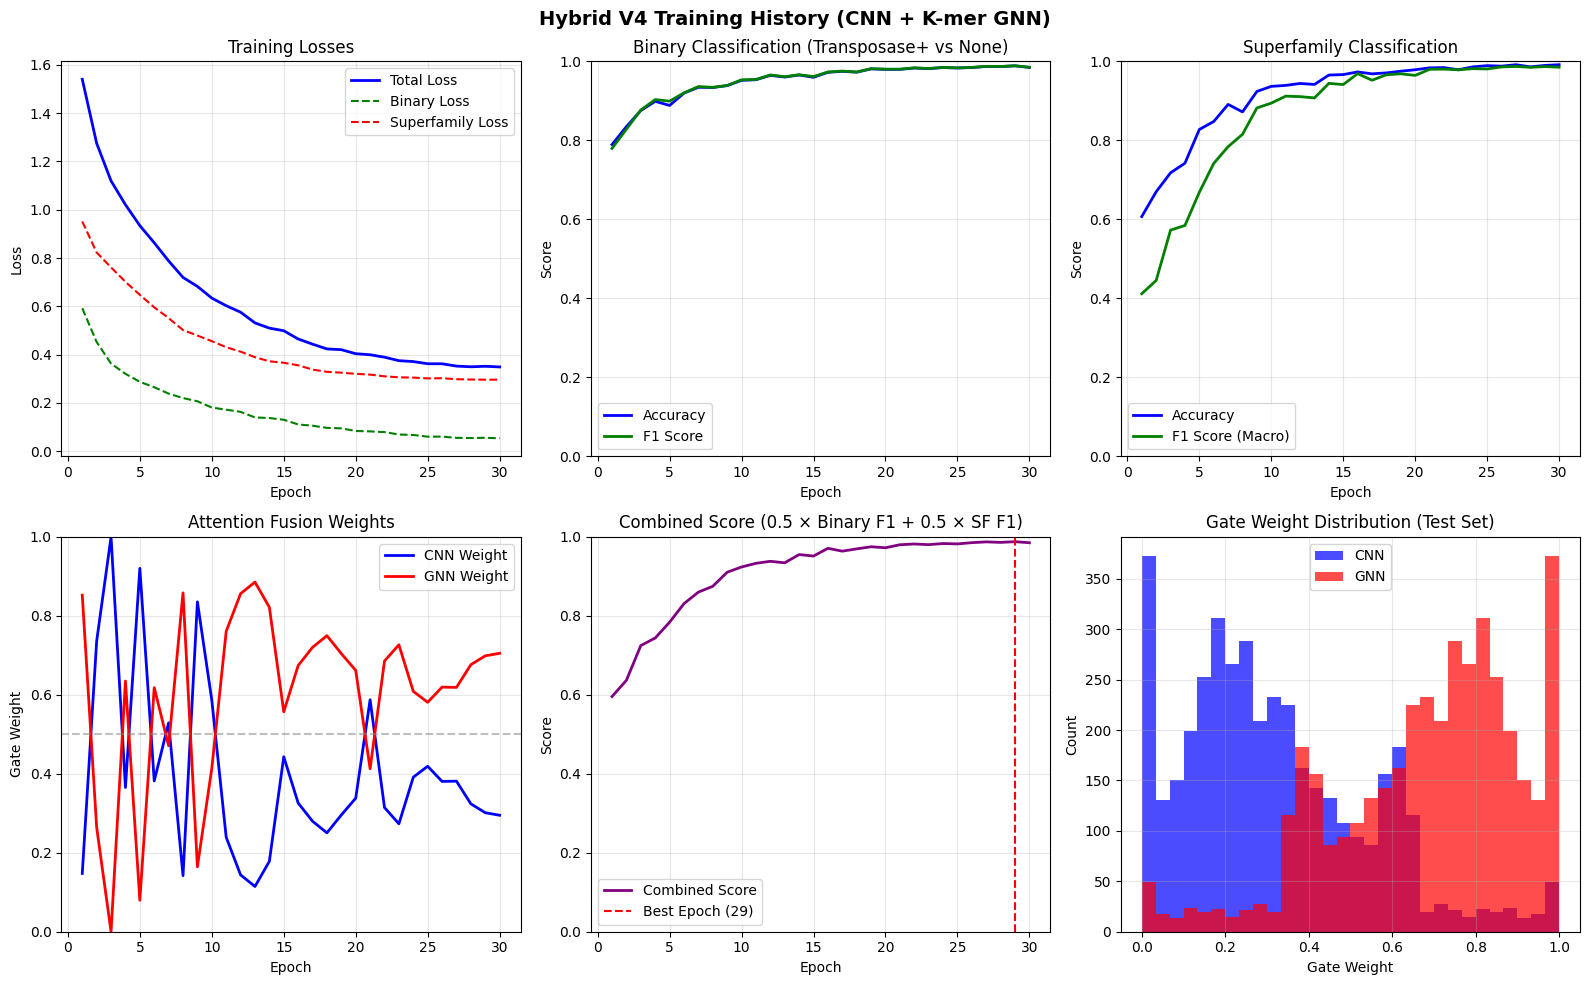

In [ ]:
# ============ Plot Training Curves ============

history = results["history"]
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Hybrid V4 Training History (CNN + K-mer GNN)", fontsize=14, fontweight="bold")

# Training losses
ax1 = axes[0, 0]
ax1.plot(epochs, history["train_loss"], "b-", label="Total Loss", linewidth=2)
ax1.plot(epochs, history["train_binary_loss"], "g--", label="Binary Loss", linewidth=1.5)
ax1.plot(epochs, history["train_sf_loss"], "r--", label="Superfamily Loss", linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Losses")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Binary metrics
ax2 = axes[0, 1]
ax2.plot(epochs, history["val_binary_acc"], "b-", label="Accuracy", linewidth=2)
ax2.plot(epochs, history["val_binary_f1"], "g-", label="F1 Score", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Score")
ax2.set_title("Binary Classification (DNA vs non-DNA)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

# Superfamily metrics
ax3 = axes[0, 2]
ax3.plot(epochs, history["val_sf_acc"], "b-", label="Accuracy", linewidth=2)
ax3.plot(epochs, history["val_sf_f1"], "g-", label="F1 Score (Macro)", linewidth=2)
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Score")
ax3.set_title("Superfamily Classification")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0, 1])

# Gate weights over training
ax4 = axes[1, 0]
ax4.plot(epochs, history["gate_weights_cnn"], "b-", label="CNN Weight", linewidth=2)
ax4.plot(epochs, history["gate_weights_gnn"], "r-", label="GNN Weight", linewidth=2)
ax4.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
ax4.set_xlabel("Epoch")
ax4.set_ylabel("Gate Weight")
ax4.set_title("Attention Fusion Weights")
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])

# Combined score
ax5 = axes[1, 1]
combined = [0.5 * b + 0.5 * s for b, s in zip(history["val_binary_f1"], history["val_sf_f1"])]
ax5.plot(epochs, combined, "purple", label="Combined Score", linewidth=2)
best_epoch = results["best_epoch"]
ax5.axvline(x=best_epoch, color="red", linestyle="--", label=f"Best Epoch ({best_epoch})")
ax5.set_xlabel("Epoch")
ax5.set_ylabel("Score")
ax5.set_title("Combined Score (0.5 × Binary F1 + 0.5 × SF F1)")
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_ylim([0, 1])

# Gate weight distribution (final)
ax6 = axes[1, 2]
ax6.hist(results["gate_weights_cnn"], bins=30, alpha=0.7, label="CNN", color="blue")
ax6.hist(results["gate_weights_gnn"], bins=30, alpha=0.7, label="GNN", color="red")
ax6.set_xlabel("Gate Weight")
ax6.set_ylabel("Count")
ax6.set_title("Gate Weight Distribution (Test Set)")
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hybrid_v4_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

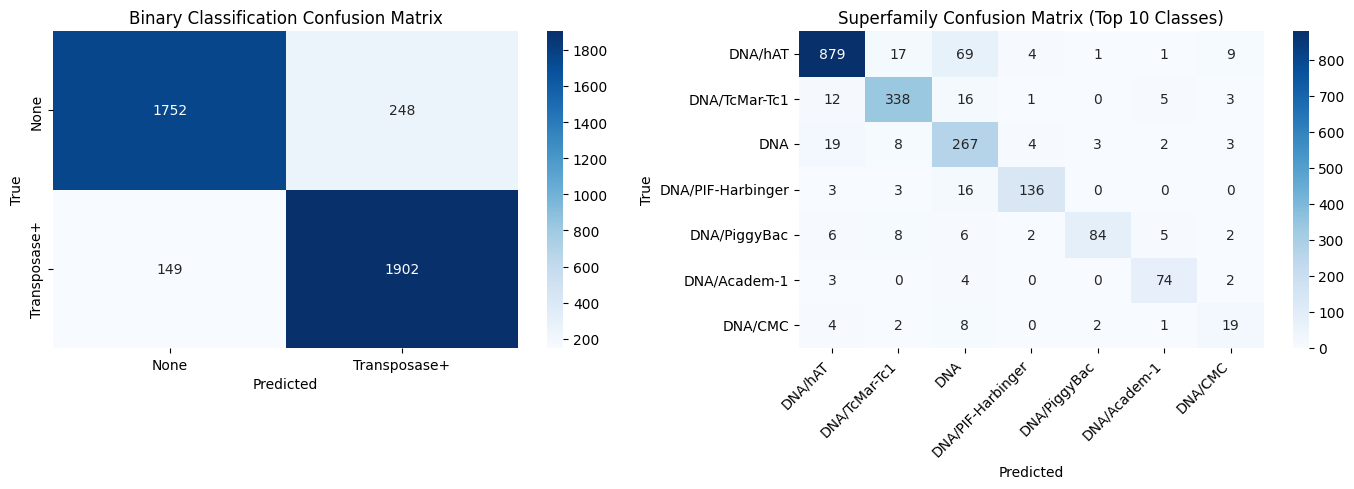

In [ ]:
# ============ Confusion Matrices ============

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary confusion matrix
ax1 = axes[0]
cm_bin = confusion_matrix(results["test_binary_true"], results["test_binary_pred"])
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Blues", ax=ax1,
            xticklabels=["None", "DNA+"],
            yticklabels=["None", "DNA+"])
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
ax1.set_title("Binary Classification Confusion Matrix")

# Superfamily confusion matrix (top classes)
ax2 = axes[1]
sf_names = results["superfamily_names"]
cm_sf = confusion_matrix(results["test_sf_true"], results["test_sf_pred"])

# Show top 10 classes by support
class_support = cm_sf.sum(axis=1)
top_classes = np.argsort(class_support)[::-1][:10]
cm_sf_top = cm_sf[np.ix_(top_classes, top_classes)]
top_names = [sf_names[i] for i in top_classes]

sns.heatmap(cm_sf_top, annot=True, fmt="d", cmap="Blues", ax=ax2,
            xticklabels=top_names, yticklabels=top_names)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")
ax2.set_title("Superfamily Confusion Matrix (Top 10 Classes)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("hybrid_v4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary & Model Comparison

In [ ]:
# ============ Final Summary ============

print("=" * 60)
print("HYBRID V4 MODEL SUMMARY")
print("=" * 60)

print(f"\\nArchitecture:")
print(f"  CNN Tower: width={CNN_WIDTH}, kernels={MOTIF_KERNELS}")
print(f"  GNN Tower: k={KMER_K}, hidden={GNN_HIDDEN}, layers={GNN_LAYERS}")
print(f"  Fusion: dim={FUSION_DIM}, heads={NUM_HEADS}")

best_idx = results["best_epoch"] - 1
history = results["history"]

print(f"\\nBest Epoch: {results['best_epoch']}")
print(f"\\nBinary Classification (DNA+ vs None):")
print(f"  Accuracy: {history['val_binary_acc'][best_idx]:.4f}")
print(f"  F1 Score: {history['val_binary_f1'][best_idx]:.4f}")

print(f"\\nSuperfamily Classification:")
print(f"  Accuracy: {history['val_sf_acc'][best_idx]:.4f}")
print(f"  Macro F1: {history['val_sf_f1'][best_idx]:.4f}")

print(f"\\nFusion Gate Weights (avg at best epoch):")
print(f"  CNN: {history['gate_weights_cnn'][best_idx]:.4f}")
print(f"  GNN: {history['gate_weights_gnn'][best_idx]:.4f}")

combined_score = 0.5 * history["val_binary_f1"][best_idx] + 0.5 * history["val_sf_f1"][best_idx]
print(f"\\nCombined Score: {combined_score:.4f}")

print(f"\\nSuperfamilies ({len(results['superfamily_names'])}): {results['superfamily_names']}")

HYBRID V4 MODEL SUMMARY
\nArchitecture:
  CNN Tower: width=128, kernels=(7, 15, 21)
  GNN Tower: k=7, hidden=128, layers=3
  Fusion: dim=256, heads=4
\nBest Epoch: 29
\nBinary Classification (Transposase+ vs None):
  Accuracy: 0.9886
  F1 Score: 0.9888
\nSuperfamily Classification:
  Accuracy: 0.9896
  Macro F1: 0.9867
\nFusion Gate Weights (avg at best epoch):
  CNN: 0.3014
  GNN: 0.6986
\nCombined Score: 0.9878
\nSuperfamilies (7): ['DNA', 'DNA/Academ-1', 'DNA/CMC', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/TcMar-Tc1', 'DNA/hAT']
